In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input# Replace 'your_filename.zip' with the actual name you uploaded
!unzip -o archive.zip

Archive:  archive.zip
  inflating: NEU-DET/train/annotations/crazing_158.xml  
  inflating: NEU-DET/train/annotations/crazing_159.xml  
  inflating: NEU-DET/train/annotations/crazing_16.xml  
  inflating: NEU-DET/train/annotations/crazing_160.xml  
  inflating: NEU-DET/train/annotations/crazing_161.xml  
  inflating: NEU-DET/train/annotations/crazing_162.xml  
  inflating: NEU-DET/train/annotations/crazing_163.xml  
  inflating: NEU-DET/train/annotations/crazing_164.xml  
  inflating: NEU-DET/train/annotations/crazing_165.xml  
  inflating: NEU-DET/train/annotations/crazing_166.xml  
  inflating: NEU-DET/train/annotations/crazing_167.xml  
  inflating: NEU-DET/train/annotations/crazing_168.xml  
  inflating: NEU-DET/train/annotations/crazing_169.xml  
  inflating: NEU-DET/train/annotations/crazing_17.xml  
  inflating: NEU-DET/train/annotations/crazing_170.xml  
  inflating: NEU-DET/train/annotations/crazing_171.xml  
  inflating: NEU-DET/train/annotations/crazing_172.xml  
  inflating

In [2]:
# The main folder that was extracted
base_dir = 'NEU-DET'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setup training and validation generators
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

# NEU-DET is already split into train/validation folders in your zip
train_generator = datagen.flow_from_directory(
    'NEU-DET/train/images', # Point to the train images
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = datagen.flow_from_directory(
    'NEU-DET/validation/images', # Point to the validation images
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.


In [3]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom Head
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [4]:
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 48s 689ms/step - accuracy: 0.2021 - loss: 1.8247 - val_accuracy: 0.1667 - val_loss: 1.7886
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 516ms/step - accuracy: 0.2458 - loss: 1.7623 - val_accuracy: 0.1722 - val_loss: 1.7581
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 517ms/step - accuracy: 0.2674 - loss: 1.7341 - val_accuracy: 0.1694 - val_loss: 1.7744
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 518ms/step - accuracy: 0.3139 - loss: 1.6907 - val_accuracy: 0.1806 - val_loss: 1.7262
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 490ms/step - accuracy: 0.3285 - loss: 1.6584 - val_accuracy: 0.3417 - val_loss: 1.6288
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 514ms/step - accuracy: 0.3160 - loss: 1.6165 - val_accuracy: 0.3389 - val_loss: 1.5876
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 514ms/step - accuracy: 0.4097 - loss: 1.5611 - val_accuracy: 0.2972 - val_loss: 1.5366
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 510ms/step - accuracy: 0.4076 - loss: 1.5152 - val_accu

In [5]:
import numpy as np
from sklearn.metrics import classification_report

# Predict the classes for the validation set
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Get the true labels
y_true = val_generator.classes

# Print the report
print(classification_report(y_true, y_pred, target_names=val_generator.class_indices.keys()))

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 668ms/step
                 precision    recall  f1-score   support

        crazing       0.00      0.00      0.00        60
      inclusion       0.18      0.58      0.28        60
        patches       0.16      0.28      0.20        60
 pitted_surface       0.00      0.00      0.00        60
rolled-in_scale       0.18      0.10      0.13        60
      scratches       0.13      0.07      0.09        60

       accuracy                           0.17       360
      macro avg       0.11      0.17      0.12       360
   weighted avg       0.11      0.17      0.12       360



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
def get_factory_decision(prediction_array):
    # Get the index of the highest probability
    class_idx = np.argmax(prediction_array)
    probability = np.max(prediction_array)

    # Logic: If confidence is high (> 85%), take action
    if probability >= 0.85:
        return f"ACTION: Trigger rejection for {list(val_generator.class_indices.keys())[class_idx]}"
    else:
        return "DECISION: Product passed (Low defect confidence)"

# Test with a single image from the validation set
# Use the Python built-in next() function
img, label = next(val_generator)

# Now run the prediction
sample_prediction = model.predict(img[0:1])
print(get_factory_decision(sample_prediction))
sample_prediction = model.predict(img[0:1])
print(get_factory_decision(sample_prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
DECISION: Product passed (Low defect confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
DECISION: Product passed (Low defect confidence)


In [7]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Freeze all layers except the last 20 (This is the "Fine-Tuning" strategy)
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. IMPORTANT: Recompile with a VERY small learning rate
# High rates will destroy the pre-trained weights
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Retrain for 5-10 more epochs
history_fine = model.fit(train_generator, validation_data=val_generator, epochs=5)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 662ms/step - accuracy: 0.4826 - loss: 2.3406 - val_accuracy: 0.2472 - val_loss: 1.7982
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 499ms/step - accuracy: 0.7736 - loss: 0.7548 - val_accuracy: 0.2222 - val_loss: 2.0743
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 518ms/step - accuracy: 0.8389 - loss: 0.5854 - val_accuracy: 0.1944 - val_loss: 2.4648
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 510ms/step - accuracy: 0.8840 - loss: 0.4838 - val_accuracy: 0.2333 - val_loss: 2.5500
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 510ms/step - accuracy: 0.8813 - loss: 0.4299 - val_accuracy: 0.2500 - val_loss: 2.5505


In [8]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),  # Added dropout to prevent overfitting
    layers.Dense(128, activation='relu'),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

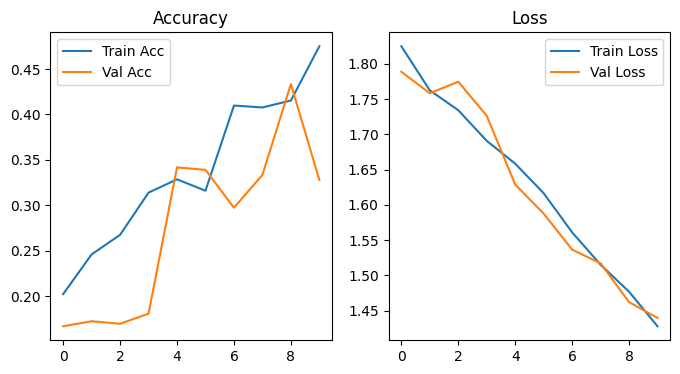

In [9]:
import matplotlib.pyplot as plt

# Assuming 'history' is the object from your first training phase
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [10]:
import os
# Point to the folder that contains your category folders
# Example: If your images are in 'NEU-DET/train/images'
data_dir = 'NEU-DET/train/images'

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

print("Data loaded successfully!")

Found 1440 images belonging to 6 classes.
Data loaded successfully!
